#  Model Training Notebook

**Description**

This notebook includes training, test, and validation set creation and model training step. The model that is used in this project is U-Net with ResNet-50 backbone. The Pre-trained model is `ResNet50_Weights.SENTINEL2_ALL_MOCO` which is available in torchgeo library.

**Input folder(s)/file(s)**

2 files
- Public Urban Green Spaces (PUGS) ground truth (`dresden_pugs_gt.geojson`)
- Sentinel-2 image stack with PUGS OSM binary mask and SDT (clipped to Dresden boundary) (`stacked_sentinel2_dresden_clipped.geotiff`)

**Output folder(s)/file(s)**

3 folders and 2 files
- Output folder for image tiles of training set (`../data/processed/tiles/train`)
- Output folder for image tiles of test set (`../data/processed/tiles/test`)
- Output folder for image tiles of validation set (`../data/processed/tiles/val`)
- The best model checkpoint (example: `epoch=47-val_loss=0.18.ckpt`)
- Metrics file (CSV file) (`metrics.csv`)
- Hyperparmeters log file (`hparams.yaml`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- 1_data_acquisition_osm.ipynb
- 1_data_acquisition_satellite_image.ipynb
- 2_data_processing_osm.ipynb
- 2_data_processing_ground_truth.ipynb
- 3_data_processing_satellite_image.ipynb
- 5_ground_truth_creation.ipynb

    **Note:** It does not require user to run `4_ground_truth_exploration.ipynb` notebook. The exploration notebook is created for understanding how each ground truth dataset complement each other and help author decide on which datasets will be used to create a final ground truth dataset.

    In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

**Remarks**

The output shown in the notebook is run from this model experiment.

- **Input**: Sentinel-2 image and PUGS binary mask derived from OSM (input channels = 14 channels)
- **Loss function**: Jaccard loss

More detail about model experiment setup can be found in [Model experiment setup](../models/README.md#model-experiment-setup)

# 1. Import libraries and load config

It can take up to 5-6 mins to complete this section.

In [1]:
import os
import sys
import yaml
# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
import torch

from torchgeo.transforms import AugmentationSequential
from tqdm import tqdm
import kornia.augmentation as K
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from torchgeo.models import ResNet50_Weights
from torch.utils.data import DataLoader
from pugs_detection.raster import create_image_tiles
from pugs_detection.modeling.model import modify_first_layer
from pugs_detection.plots import plot_image_tiles, visualize_from_torchgeo_dataloader
from pugs_detection.modeling.segmentation_task import CustomSegmentationTask
from pugs_detection.utils import set_all_seeds
from pugs_detection.dataset import create_dataset_split

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information when converting to a PROJ string from another format.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired.*",
    category=UserWarning,
)

In [4]:
# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)


# 2. Set seed to make it reproducible

In [5]:
# Set seeds for reproducibility
seed = config["general"]["seed"]
set_all_seeds(seed)

Seed set to 10


In [6]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

# 3. Set variables

In [7]:
train_index_list = config["data"]["train_index_list"]
val_index_list = config["data"]["val_index_list"]
test_index_list = config["data"]["test_index_list"]

output_folder_path = config["paths"]["tiles_folder_path"]
image_path = config["paths"]["clipped_image_path"]

# Define paths for pre-split tiles
train_image_path = config["paths"]["train_image_path"]
val_image_path = config["paths"]["val_image_path"]
test_image_path = config["paths"]["test_image_path"]
# Vector data path
label_path = config["paths"]["gt_vector_path"]

# band_list = config["data"]["band_list"]
# hier setting bands considering the experiment version, as band_list is defined in each experiment version in config.yaml
band_list = config["models"][config["model"]["version"]]["band_list"]
num_channels = len(band_list)

crs = config["data"]["crs"]

In [8]:
print(config["models"][config["model"]["version"]])
print(band_list, len(band_list))


{'band_list': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'loss_func': 'jaccard', 'version': 0}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] 13


# 4. Create image tiles for training, validation, and test set

Manually specify the tiles to training, validation, and test set

In [9]:
all_tiles_list = create_image_tiles(
    output_folder_path, image_path, train_index_list, val_index_list, test_index_list
)

Image bounds width: 27110.0 height: 22640.0
Tile dimensions width: 5422.0 height: 4528.0
Skipping tile 1: only 0.0% valid data
Tile 2 already exists. Skipping.
Tile 3 already exists. Skipping.
Skipping tile 4: only 7.0% valid data
Skipping tile 5: only 0.0% valid data
Skipping tile 6: only 13.2% valid data
Tile 7 already exists. Skipping.
Tile 8 already exists. Skipping.
Tile 9 already exists. Skipping.
Skipping tile 10: only 0.8% valid data
Tile 11 already exists. Skipping.
Tile 12 already exists. Skipping.
Tile 13 already exists. Skipping.
Tile 14 already exists. Skipping.
Tile 15 already exists. Skipping.
Tile 16 already exists. Skipping.
Tile 17 already exists. Skipping.
Tile 18 already exists. Skipping.
Tile 19 already exists. Skipping.
Tile 20 already exists. Skipping.
Skipping tile 21: only 14.5% valid data
Tile 22 already exists. Skipping.
Tile 23 already exists. Skipping.
Skipping tile 24: only 5.1% valid data
Skipping tile 25: only 0.3% valid data
Processing complete: 17 vali

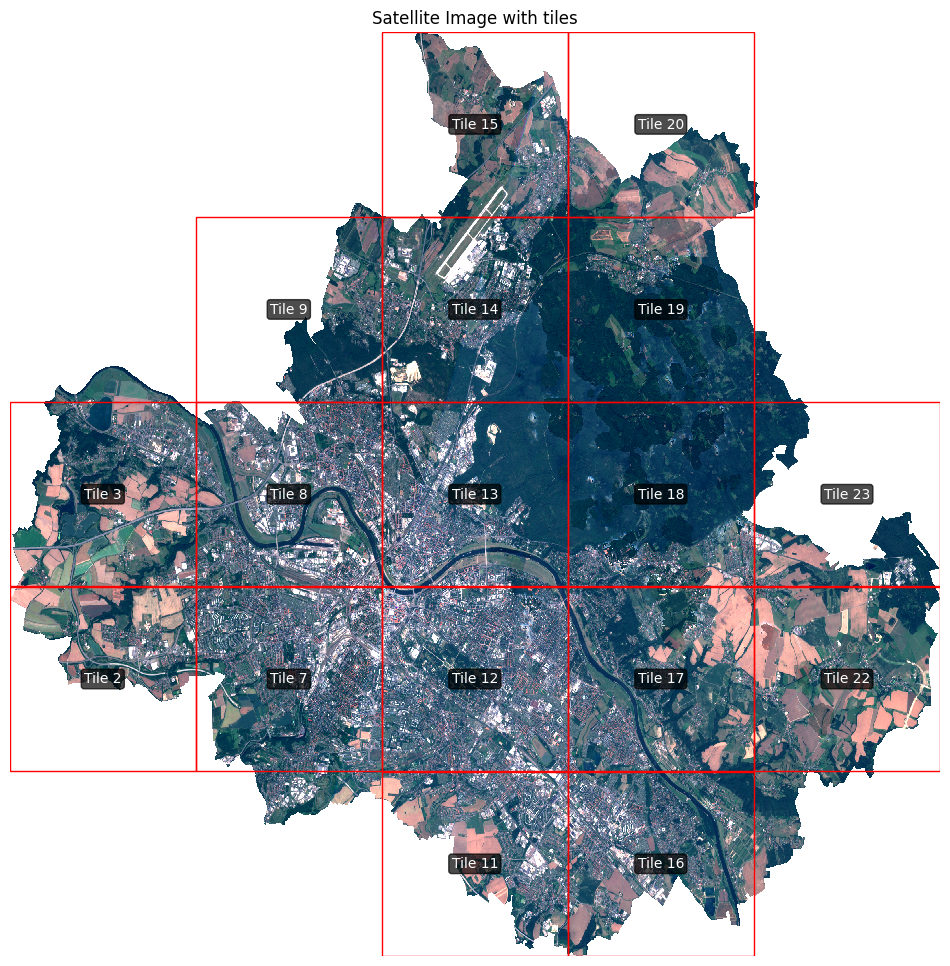

In [10]:
plot_image_tiles(image_path, all_tiles_list)


# 5. Creating image patches

In [11]:
# Create specific augmentation transforms
h_flip_transform = AugmentationSequential(
    K.RandomHorizontalFlip(p=1.0), data_keys=["image", "mask"]
)

v_flip_transform = AugmentationSequential(
    K.RandomVerticalFlip(p=1.0), data_keys=["image", "mask"]
)

rotation_transform = AugmentationSequential(
    K.RandomRotation(degrees=45, p=1.0, align_corners=True), data_keys=["image", "mask"]
)

In [12]:
# Create list of specific transforms
transform_list = [h_flip_transform, v_flip_transform, rotation_transform]

## Create training dataset

In [13]:
# Create the filtered datasets

train_dataset = create_dataset_split(
    train_image_path, label_path, crs, band_list, "train", transform_list, seed
)

Seed set to 10
Filtering patches for train: 100%|██████████| 132/132 [00:57<00:00,  2.31patch/s]

Found 123 valid patches out of 132 total patches


In [14]:
print(len(train_dataset))

492


In [15]:
if config["general"]["os"] == "linux":
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["model"]["batch_size"],
        shuffle=True,
        collate_fn=stack_samples,
        num_workers=config["model"]["training_num_workers"],
        persistent_workers=True
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["model"]["batch_size"],
        shuffle=True,
        collate_fn=stack_samples,
    )

In [16]:
len(train_loader)

31

In [17]:
# dataiter = iter(train_loader)

In [18]:
# comment for now to debug
# if num_channels > 13:
    #visualize_from_torchgeo_dataloader(train_loader, 8, "additional", [13])  # visualizing 8 samples
# else:
    #visualize_from_torchgeo_dataloader(train_loader, 8, "original")

## Create validation dataset

Set transform_sequence to None by default or optional params

In [19]:
val_dataset = create_dataset_split(
    val_image_path, label_path, crs, band_list, "validation", None, seed
)

Seed set to 10


Using all 36 patches for validation set


In [20]:
if config["general"]["os"] == "linux":
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["model"]["batch_size"],
        collate_fn=stack_samples,
        num_workers=config["model"]["validation_num_workers"],
        persistent_workers=True
    )
else:
    val_loader = DataLoader(
        val_dataset, batch_size=config["model"]["batch_size"], collate_fn=stack_samples,
    )

In [21]:
# dataiter = iter(val_loader)

In [22]:
# comment for now to debug
# if num_channels > 13:
#  visualize_from_torchgeo_dataloader(val_loader, 3, "additional", [13])
#
# else:
#   visualize_from_torchgeo_dataloader(val_loader, 3, "original") """

## Create test dataset

Set transform_sequence to None by default or optional params

In [23]:
test_dataset = create_dataset_split(
    test_image_path, label_path, crs, band_list, "test", None, seed
)

Seed set to 10


Using all 36 patches for test set


In [24]:
if config["general"]["os"] == "linux":
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["model"]["batch_size"],
        collate_fn=stack_samples,
        num_workers=config["model"]["test_num_workers"],
        persistent_workers=True
    )
else:
    test_loader = DataLoader(
        test_dataset, batch_size=config["model"]["batch_size"], collate_fn=stack_samples
    )

In [25]:
len(test_loader)

3

In [26]:
# dataiter = iter(test_loader)

In [27]:
# Comment for now
# if num_channels > 13:
   # visualize_from_torchgeo_dataloader(test_loader, 3, "additional", [13])
# else:
   # visualize_from_torchgeo_dataloader(test_loader, 3, "original")

# 6. Create and train model

In [28]:
if config["model"]["weight"] == "SENTINEL2_ALL_MOCO":
    weight = ResNet50_Weights.SENTINEL2_ALL_MOCO
else:
    # there is other weights available in TorchGeo library as well, but for now
    # using only the SENTINEL2_ALL_MOCO
    weight = ResNet50_Weights.SENTINEL2_ALL_MOCO

## Define Model

In [29]:
if num_channels > 13:
    task = CustomSegmentationTask(
     
        loss=config["models"][config["model"]["version"]]["loss_func"],
        model=config["model"]["architecture"],
        backbone=config["model"]["backbone"],
        weights=weight,
        in_channels=13,
        num_classes=1,
        lr=config["model"]["learning_rate"],
        patience=5,
    )

    task = modify_first_layer(task, in_channels=num_channels)
else:
    task = CustomSegmentationTask(
        loss=config["models"][config["model"]["version"]]["loss_func"],
        model=config["model"]["architecture"],
        backbone=config["model"]["backbone"],
        weights=weight,
        in_channels=num_channels,
        num_classes=1,
        lr=config["model"]["learning_rate"],
        patience=5,
    )

here {'loss': 'jaccard', 'model': 'unet', 'backbone': 'resnet50', 'weights': ResNet50_Weights.SENTINEL2_ALL_MOCO, 'in_channels': 13, 'num_classes': 1, 'lr': 0.0001, 'patience': 5}


## Training

In [30]:
checkpoint_callback = ModelCheckpoint(
    filename="{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=1,  # Save checkpoint with the best validation loss
)
early_stopping = EarlyStopping(monitor="val_loss", patience=config["model"]["patience"])
# configure logger path to include the seed value in the path
logger_path = config["paths"]["logger_path"].format(seed=config["general"]["seed"])
logger = CSVLogger(
    logger_path, name=config["paths"]["checkpoint_folder"], version=config["model"]["version"]
)
print(f"Logger path: {logger.log_dir}")

Logger path: ../s10/models\trained_models\version_0


In [31]:
trainer = Trainer(
    max_epochs=config["model"]["epochs"],
    deterministic=True,
    accelerator=config["model"]["accelerator"],
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [32]:
trainer.fit(model=task, train_dataloaders=train_loader, val_dataloaders=val_loader)

You are using a CUDA device ('NVIDIA RTX 2000 Ada Generation Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
d:\research_line\PUGS\code_resubmission\pugs-detection\.venv\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory ../s10/models\trained_models\version_0 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
d:\research_line\PUGS\code_resubmission\pugs-detection\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:654: Checkpoint directory ../s10/models\trained_models\version_0\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params | Mode 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\research_line\PUGS\code_resubmission\pugs-detection\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.
d:\research_line\PUGS\code_resubmission\pugs-detection\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
